<a href="https://colab.research.google.com/github/anshulkr69/CryptoTier-ML/blob/main/dataIngestion_and_modelTraining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

In [2]:
# Data ingestion thru api

import requests
from google.colab import userdata

api_key = userdata.get('api_key')
url = "https://api.coingecko.com/api/v3/coins/markets"

page = 1
query = {"x_cg_demo_api_key":f'{api_key}', 'vs_currency':'inr', 'page':page}

response = requests.get(url, params = query)
response.status_code

200

In [3]:
response.json()[0]

{'id': 'bitcoin',
 'symbol': 'btc',
 'name': 'Bitcoin',
 'image': 'https://coin-images.coingecko.com/coins/images/1/large/bitcoin.png?1696501400',
 'current_price': 6217483,
 'market_cap': 124723010664960,
 'market_cap_rank': 1,
 'fully_diluted_valuation': 124723010664960,
 'total_volume': 1538113673546,
 'high_24h': 6268613,
 'low_24h': 6178907,
 'price_change_24h': 24663,
 'price_change_percentage_24h': 0.39825,
 'market_cap_change_24h': 497276932946,
 'market_cap_change_percentage_24h': 0.4003,
 'circulating_supply': 20058503.0,
 'total_supply': 20058503.0,
 'max_supply': 21000000.0,
 'ath': 11187013,
 'ath_change_percentage': -44.42231,
 'ath_date': '2025-10-06T18:57:42.558Z',
 'atl': 3993.42,
 'atl_change_percentage': 155593.21526,
 'atl_date': '2013-07-05T00:00:00.000Z',
 'roi': None,
 'last_updated': '2026-07-19T13:06:35.851Z'}

In [4]:
res = []
res.append(response.json())
print(res)

[[{'id': 'bitcoin', 'symbol': 'btc', 'name': 'Bitcoin', 'image': 'https://coin-images.coingecko.com/coins/images/1/large/bitcoin.png?1696501400', 'current_price': 6217483, 'market_cap': 124723010664960, 'market_cap_rank': 1, 'fully_diluted_valuation': 124723010664960, 'total_volume': 1538113673546, 'high_24h': 6268613, 'low_24h': 6178907, 'price_change_24h': 24663, 'price_change_percentage_24h': 0.39825, 'market_cap_change_24h': 497276932946, 'market_cap_change_percentage_24h': 0.4003, 'circulating_supply': 20058503.0, 'total_supply': 20058503.0, 'max_supply': 21000000.0, 'ath': 11187013, 'ath_change_percentage': -44.42231, 'ath_date': '2025-10-06T18:57:42.558Z', 'atl': 3993.42, 'atl_change_percentage': 155593.21526, 'atl_date': '2013-07-05T00:00:00.000Z', 'roi': None, 'last_updated': '2026-07-19T13:06:35.851Z'}, {'id': 'ethereum', 'symbol': 'eth', 'name': 'Ethereum', 'image': 'https://coin-images.coingecko.com/coins/images/279/large/ethereum.png?1696501628', 'current_price': 180388, '

In [5]:
len(response.json())

100

In [6]:
from collections import deque
res = deque([])
for i in range(10):
  page = i+1
  query = {"x_cg_demo_api_key":f'{api_key}', 'vs_currency':'inr', 'page':f"{page}"}

  response = requests.get(url, params = query)
  res.extend(response.json())
len(res)

1000

In [7]:
# We will extract only the useful features from the dataset to predict the rank of a cryptocoin
extract_cols = ['current_price','market_cap','fully_diluted_valuation','total_volume','price_change_percentage_24h','market_cap_change_percentage_24h','circulating_supply','total_supply','max_supply','ath', 'ath_change_percentage','atl','atl_change_percentage','market_cap_rank']

In [8]:
data = deque()
for i in res:
  data.extend(i[k] for k in extract_cols)

In [9]:
# reshaping the data.
data_arr = np.reshape(np.array(data),(int(14000/len(extract_cols)),len(extract_cols)))

In [10]:
data_arr.shape

(1000, 14)

In [11]:
raw_df = pd.DataFrame(data_arr, columns = extract_cols)
raw_df.head()

,current_price,market_cap,fully_diluted_valuation,total_volume,price_change_percentage_24h,market_cap_change_percentage_24h,circulating_supply,total_supply,max_supply,ath,ath_change_percentage,atl,atl_change_percentage,market_cap_rank
0,6217483,124723010664960,124723010664960,1538113673546,0.39825,0.4003,20058503.0,20058503.0,21000000.0,11187013,-44.42231,3993.42,155593.21526,1
1,180388,21772736817722,21772736817722,516919483629,1.35062,1.36205,120682834.547699,120682834.547699,None,431946,-58.23822,28.13,641137.91368,2
2,96.57,17789725391971,18317646356513,2393938150331,-0.0039,-0.00391,184223396522.251404,189690338312.546204,None,105.52,-8.48348,36.86,161.98628,3
3,54820,7301083557531,7301083557531,39085361396,-0.51418,-0.50493,133165973.21,133165973.21,200000000.0,121422,-54.85142,2.58,2120823.45836,4
4,96.62,7081930005300,7081958661288,441647256042,-0.00474,-0.00971,73292808767.656296,73293105336.229782,None,97.12,-0.50303,65.31,47.95767,5


In [12]:
# Now there is very obvious column that needs to be dropped!!

raw_df.drop('market_cap',axis = 1,inplace = True)

In [13]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   current_price                     1000 non-null   object
 1   fully_diluted_valuation           1000 non-null   object
 2   total_volume                      956 non-null    object
 3   price_change_percentage_24h       976 non-null    object
 4   market_cap_change_percentage_24h  976 non-null    object
 5   circulating_supply                1000 non-null   object
 6   total_supply                      1000 non-null   object
 7   max_supply                        632 non-null    object
 8   ath                               1000 non-null   object
 9   ath_change_percentage             1000 non-null   object
 10  atl                               1000 non-null   object
 11  atl_change_percentage             1000 non-null   object
 12  market_cap_rank      

In [14]:
raw_df.drop('max_supply',axis = 1, inplace = True)

dropped max_supply because it had only ~60% data.

In [15]:
raw_df.describe().T

,count,unique,top,freq
current_price,1000.0,893.0,9.664000e+01,20.0
fully_diluted_valuation,1000.0,1000.0,6.160782e+09,1.0
total_volume,956.0,951.0,0.000000e+00,6.0
price_change_percentage_24h,976.0,932.0,0.000000e+00,42.0
market_cap_change_percentage_24h,976.0,938.0,0.000000e+00,37.0
circulating_supply,1000.0,945.0,1.000000e+09,21.0
total_supply,1000.0,727.0,1.000000e+09,125.0
ath,1000.0,957.0,9.701000e+01,12.0
ath_change_percentage,1000.0,979.0,-3.858500e-01,10.0
atl,1000.0,938.0,8.532000e+01,12.0


In [16]:
# Lets see the heatmap

corr = raw_df.corr()

In [17]:
corr

,current_price,fully_diluted_valuation,total_volume,price_change_percentage_24h,market_cap_change_percentage_24h,circulating_supply,total_supply,ath,ath_change_percentage,atl,atl_change_percentage,market_cap_rank
current_price,1.000000,0.551524,0.301510,-0.001201,-0.002577,-0.002456,-0.002378,-0.001331,0.075139,0.818087,-0.002308,-0.030030
fully_diluted_valuation,0.551524,1.000000,0.662955,-0.001393,-0.002198,-0.001987,-0.001929,-0.001155,0.041348,-0.002987,-0.001952,-0.096266
total_volume,0.301510,0.662955,1.000000,0.003055,-0.002199,-0.002187,-0.002127,0.340920,0.071448,-0.003227,-0.002149,-0.108274
price_change_percentage_24h,-0.001201,-0.001393,0.003055,1.000000,0.055841,-0.002657,-0.002741,-0.003251,0.018651,-0.000704,-0.003239,0.000307
market_cap_change_percentage_24h,-0.002577,-0.002198,-0.002199,0.055841,1.000000,-0.001370,-0.001336,-0.001312,-0.026293,-0.002066,-0.001308,0.007767
circulating_supply,-0.002456,-0.001987,-0.002187,-0.002657,-0.001370,1.000000,0.999952,-0.001068,-0.026092,-0.001945,-0.001065,-0.011198
total_supply,-0.002378,-0.001929,-0.002127,-0.002741,-0.001336,0.999952,1.000000,-0.001034,-0.025467,-0.001883,-0.001031,-0.011050
ath,-0.001331,-0.001155,0.340920,-0.003251,-0.001312,-0.001068,-0.001034,1.000000,-0.029435,-0.001130,-0.001004,-0.036491
ath_change_percentage,0.075139,0.041348,0.071448,0.018651,-0.026293,-0.026092,-0.025467,-0.029435,1.000000,0.073123,-0.027368,-0.184543
atl,0.818087,-0.002987,-0.003227,-0.000704,-0.002066,-0.001945,-0.001883,-0.001130,0.073123,1.000000,-0.001828,0.007310


<Axes: >

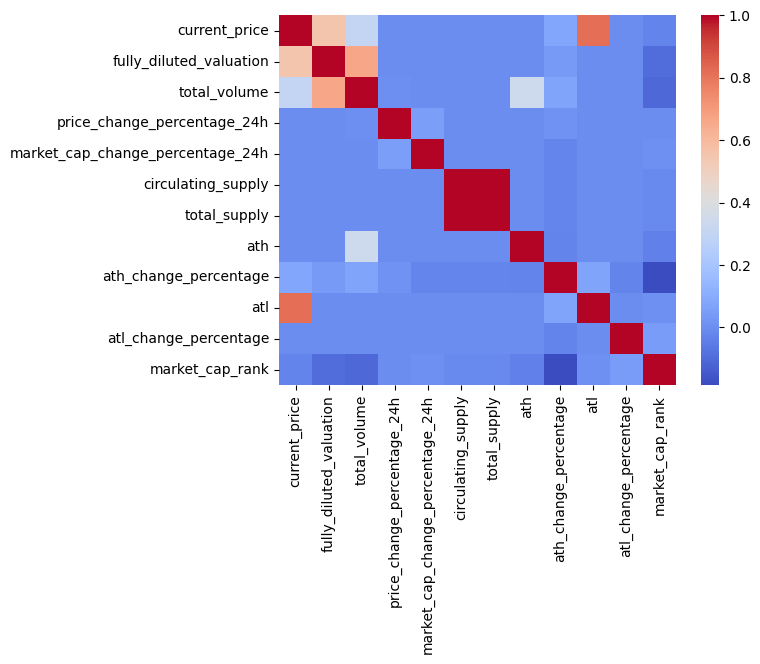

In [18]:
from matplotlib.colors import Colormap
import seaborn as sns

sns.heatmap(corr,cmap = 'coolwarm')

In [19]:
!pip install ydata_profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.5 MB/s eta 0:00:00


In [20]:
from ydata_profiling import ProfileReport

/tmp/ipykernel_848/44057814.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [21]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   current_price                     1000 non-null   object
 1   fully_diluted_valuation           1000 non-null   object
 2   total_volume                      956 non-null    object
 3   price_change_percentage_24h       976 non-null    object
 4   market_cap_change_percentage_24h  976 non-null    object
 5   circulating_supply                1000 non-null   object
 6   total_supply                      1000 non-null   object
 7   ath                               1000 non-null   object
 8   ath_change_percentage             1000 non-null   object
 9   atl                               1000 non-null   object
 10  atl_change_percentage             1000 non-null   object
 11  market_cap_rank                   1000 non-null   object
dtypes: object(12)
memory 

In [22]:
raw_df.dropna(inplace = True)

In [23]:
# This will give error if we dont change the data types to numeric type

raw_df = raw_df.astype(dtype = 'float')
raw_df.shape

(935, 12)

In [24]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 935 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   current_price                     935 non-null    float64
 1   fully_diluted_valuation           935 non-null    float64
 2   total_volume                      935 non-null    float64
 3   price_change_percentage_24h       935 non-null    float64
 4   market_cap_change_percentage_24h  935 non-null    float64
 5   circulating_supply                935 non-null    float64
 6   total_supply                      935 non-null    float64
 7   ath                               935 non-null    float64
 8   ath_change_percentage             935 non-null    float64
 9   atl                               935 non-null    float64
 10  atl_change_percentage             935 non-null    float64
 11  market_cap_rank                   935 non-null    float64
dtypes: float64(12

In [25]:
# profile = ProfileReport(raw_df, title = 'Crypto coins EDA', minimal = True)
# profile.to_file('/content/drive/MyDrive/Datasets/crypto_coins_report.html')

In [26]:
# Turning the target column into quantiles

quantiles = [0.0, 0.1, 0.25, 0.50, 0.75, 1.0]
labels = ['Top 10%', 'Top 25%', 'Top 50%', 'Top 75%', 'Rest']

raw_df['market_percentile'] = pd.qcut(raw_df.market_cap_rank, q = quantiles, labels = labels)

In [27]:
raw_df.drop(['fully_diluted_valuation','market_cap_rank'], axis = 1, inplace = True)

In [28]:
raw_df.sample(5)

,current_price,total_volume,price_change_percentage_24h,market_cap_change_percentage_24h,circulating_supply,total_supply,ath,ath_change_percentage,atl,atl_change_percentage,market_percentile
637,2.34,3.722858e+08,0.80923,0.82211,1.244272e+09,2.100000e+09,507.01,-99.53787,2.180000,7.71465,Top 75%
766,33.73,1.339031e+08,-1.15592,-1.22027,6.419381e+07,1.053699e+08,2238.48,-98.49025,31.180000,8.39643,Rest
362,17.61,3.447750e+05,0.02598,0.02232,3.474087e+08,1.600000e+09,24.24,-27.35883,0.034986,50234.81522,Top 50%
430,1.72,4.797224e+07,-1.63183,-1.55937,2.851708e+09,2.851708e+09,7.64,-77.50705,0.268609,539.47675,Top 50%
499,4.16,1.025903e+09,1.44572,1.70853,9.799787e+08,9.799787e+08,173.58,-97.60116,0.315571,1219.47597,Top 50%


In [29]:
raw_df.shape

(935, 11)

In [139]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(raw_df.iloc[:,0:-1], raw_df.iloc[:,-1], test_size = 0.2, random_state = 42)

In [147]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators = 150,oob_score = True)
rf.fit(X_train, y_train)
rf.oob_score_

0.5815508021390374

In [144]:
importance = pd.Series(rf.feature_importances_, index = raw_df.columns[:-1])

In [133]:
importance.sort_values(ascending = True, inplace = True)

In [134]:
importance

,0
market_cap_change_percentage_24h,0.069141
price_change_percentage_24h,0.073011
ath,0.078223
ath_change_percentage,0.079445
atl_change_percentage,0.080350
atl,0.086040
total_supply,0.111898
current_price,0.129187
circulating_supply,0.143431
total_volume,0.149274


<BarContainer object of 10 artists>

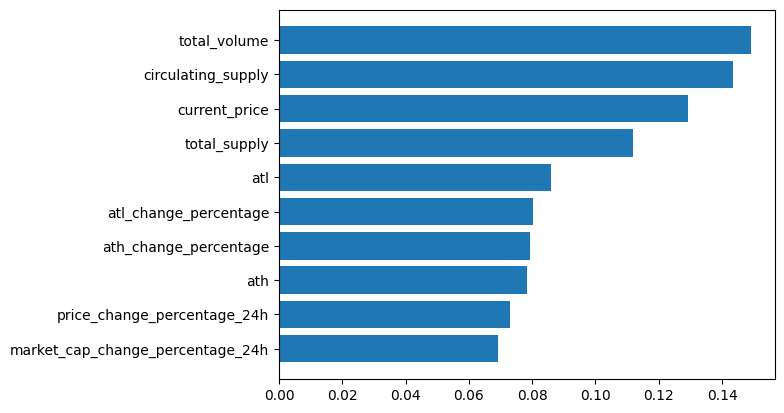

In [135]:
import matplotlib.pyplot as plt

plt.barh(importance.index , importance.values)

In [148]:
from sklearn.metrics import classification_report

y_pred = rf.predict(X_test)

In [149]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        Rest       0.65      0.70      0.67        46
     Top 10%       0.86      0.60      0.71        20
     Top 25%       0.43      0.45      0.44        22
     Top 50%       0.63      0.63      0.63        54
     Top 75%       0.57      0.60      0.59        45

    accuracy                           0.61       187
   macro avg       0.63      0.60      0.61       187
weighted avg       0.62      0.61      0.62       187



In [150]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[32,  0,  0,  3, 11],
       [ 0, 12,  8,  0,  0],
       [ 1,  1, 10, 10,  0],
       [ 6,  0,  5, 34,  9],
       [10,  1,  0,  7, 27]])

### Standardizing the data then applying RandomForest and Logistic regression in order to get a comparision of how metrics and result changed and what worked better.

In [73]:
X = raw_df.iloc[:, 0:-1]
y = raw_df.iloc[:,-1]

In [58]:
X.describe()

,current_price,total_volume,price_change_percentage_24h,market_cap_change_percentage_24h,circulating_supply,total_supply,ath,ath_change_percentage,atl,atl_change_percentage
count,9.350000e+02,9.350000e+02,935.000000,935.000000,9.350000e+02,9.350000e+02,9.350000e+02,935.000000,9.350000e+02,9.350000e+02
mean,2.441519e+04,6.422281e+09,0.689116,4.759839,2.089118e+14,4.626224e+14,4.716544e+04,-69.815841,1.367188e+04,9.135565e+31
std,3.530111e+05,9.566873e+10,6.661585,114.088747,6.004490e+15,1.373547e+16,5.630924e+05,34.056247,2.513260e+05,2.793452e+33
min,2.902400e-08,0.000000e+00,-14.435860,-14.392720,5.440000e+02,5.440000e+02,5.514990e-07,-99.999940,0.000000e+00,-1.568800e-01
25%,1.700000e+00,1.775837e+07,-0.639015,-0.654105,8.097038e+07,1.000000e+08,2.136500e+01,-96.898390,4.522840e-01,1.787955e+01
50%,1.279000e+01,1.881069e+08,0.017400,0.048080,5.501405e+08,1.000000e+09,1.023100e+02,-87.463070,4.260000e+00,7.651092e+01
75%,9.661500e+01,6.249617e+08,1.285590,1.366575,2.905268e+09,8.189222e+09,7.074150e+02,-50.940170,4.796500e+01,5.421991e+02
max,6.234780e+06,2.393938e+12,149.187720,3477.235800,1.835881e+17,4.200000e+17,1.118701e+07,0.000000,5.506848e+06,8.541753e+34


In [151]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

<Axes: xlabel='current_price', ylabel='Density'>

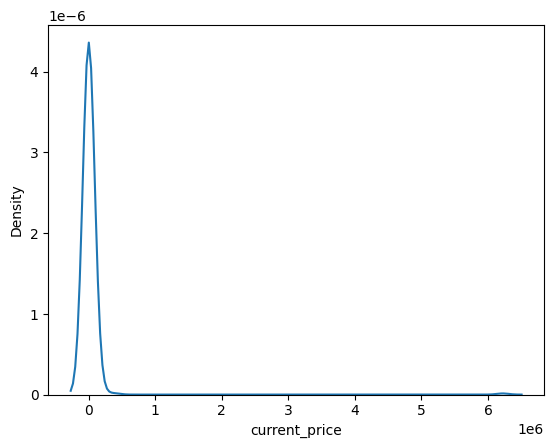

In [152]:
sns.kdeplot(X.current_price)

clearly there is a lot of skewness in the data.

In [153]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer()
X_train_transform = pt.fit_transform(X_train)
X_test_transform = pt.transform(X_test)

In [154]:
def kde(column_index):
  # Create 1 row with 2 distinct plotting axes side-by-side
  fig, axes = plt.subplots(1, 2, figsize=(14, 5))

  # Plot on the first axis (left)
  sns.kdeplot(X_train_transform[:, column_index], ax=axes[0], color="darkorange")
  axes[0].set_title("Transformed Feature")

  # Plot on the second axis (right)
  sns.kdeplot(X_train.iloc[:, column_index], ax=axes[1], color="navy")
  axes[1].set_title("Original Feature")

  plt.tight_layout()
  plt.show()

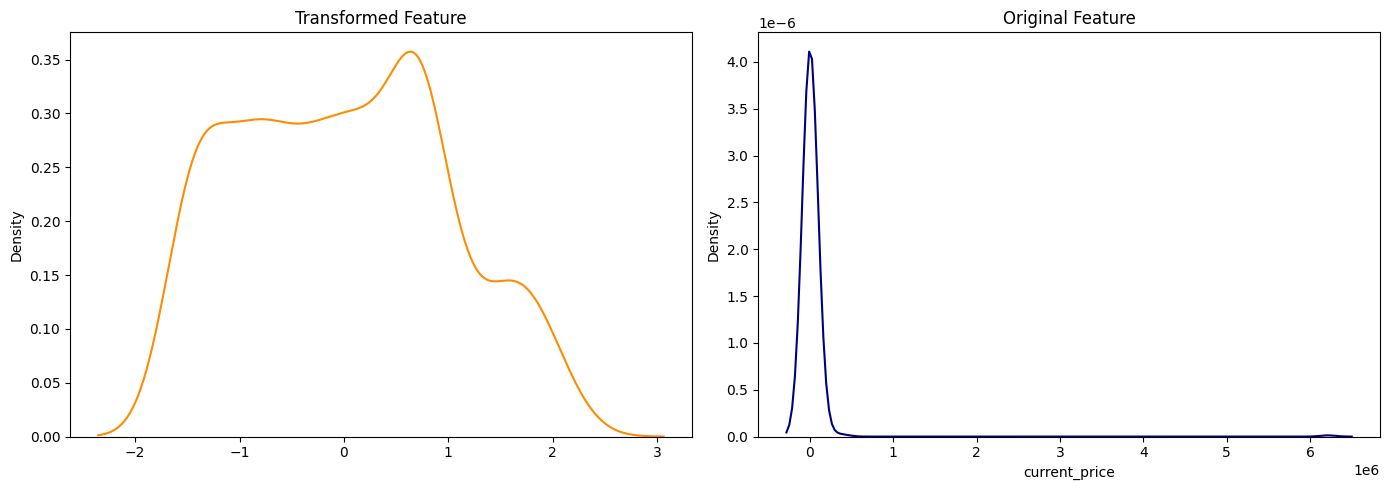

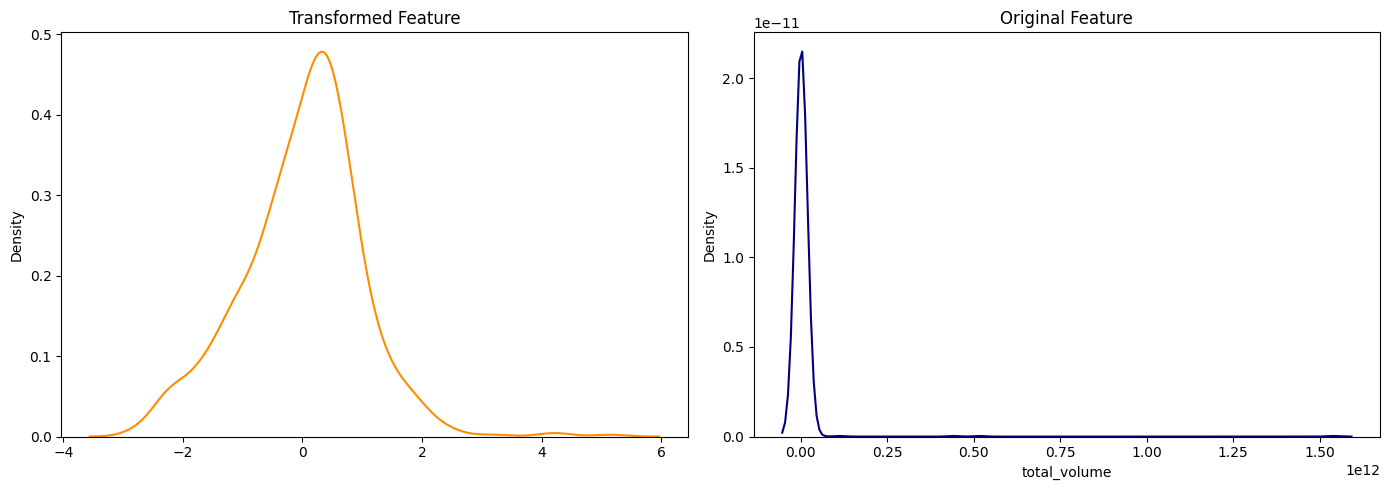

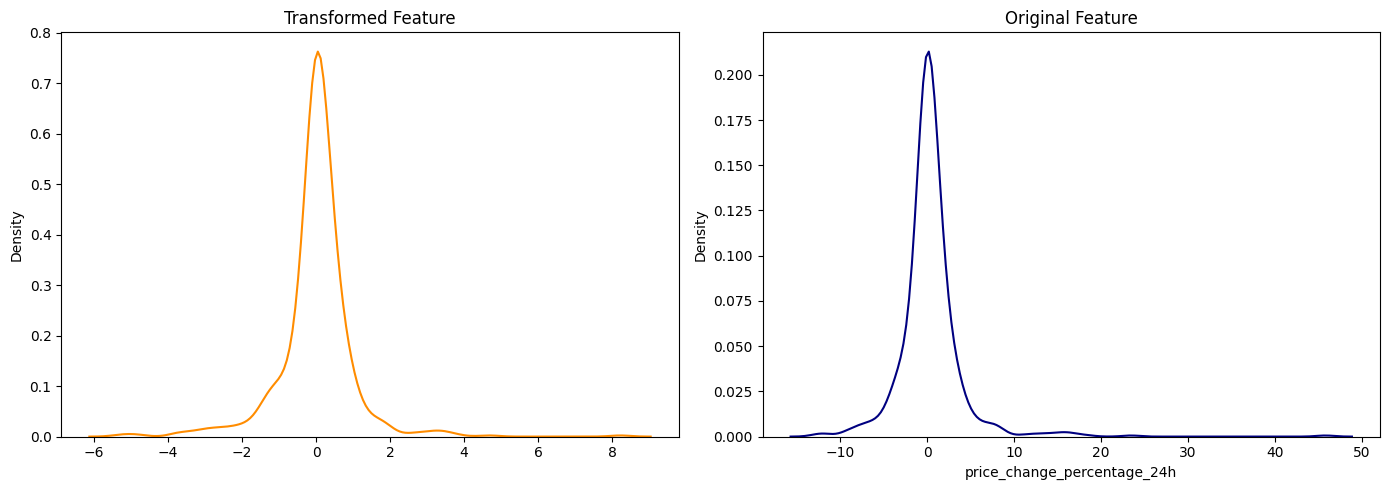

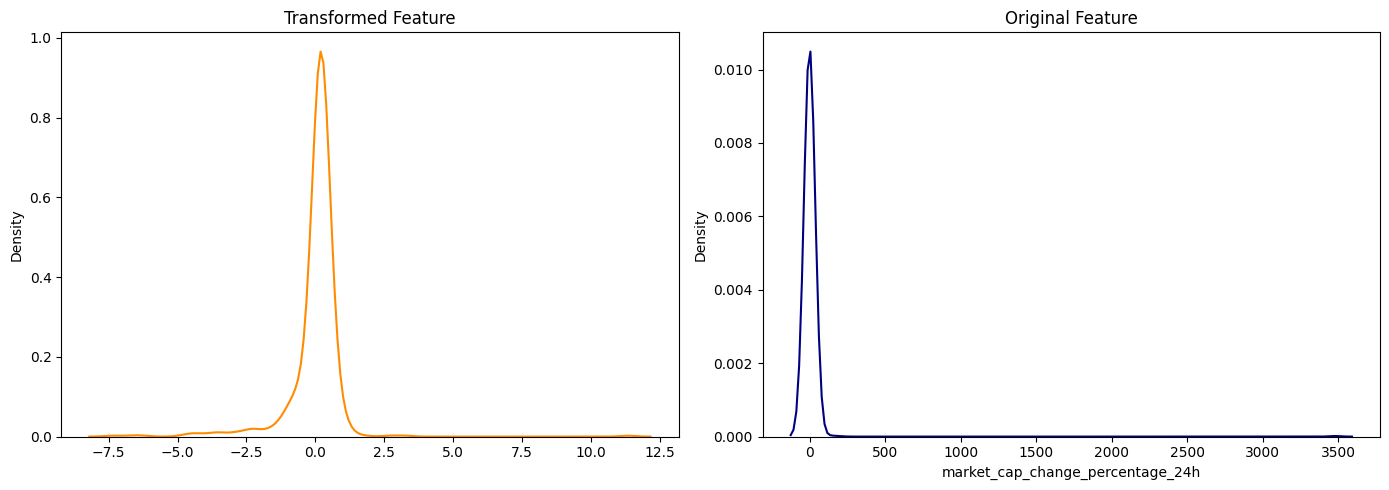

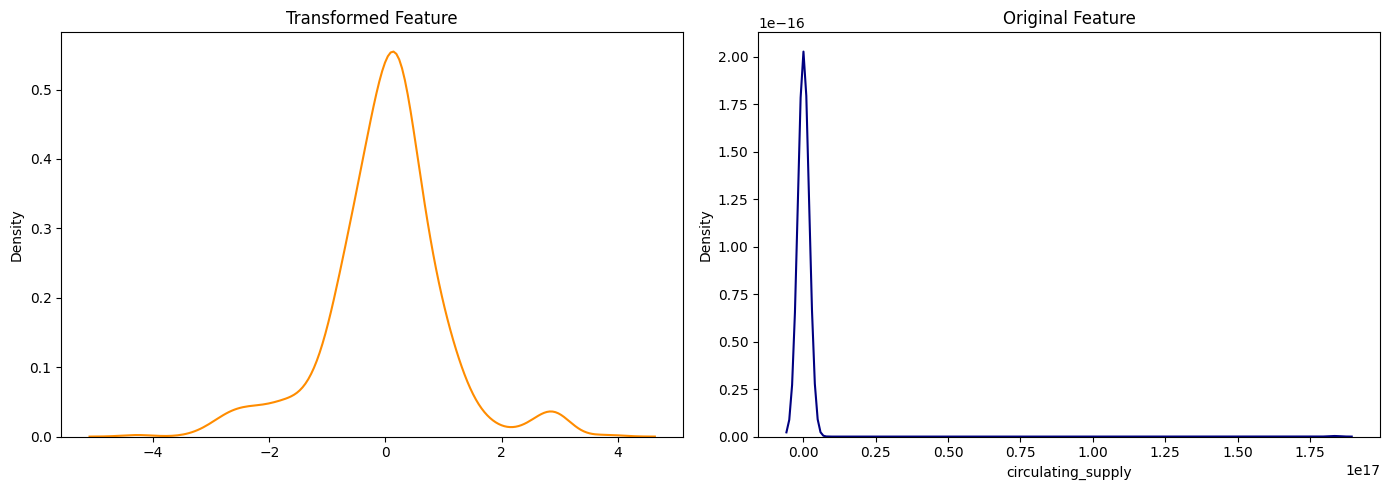

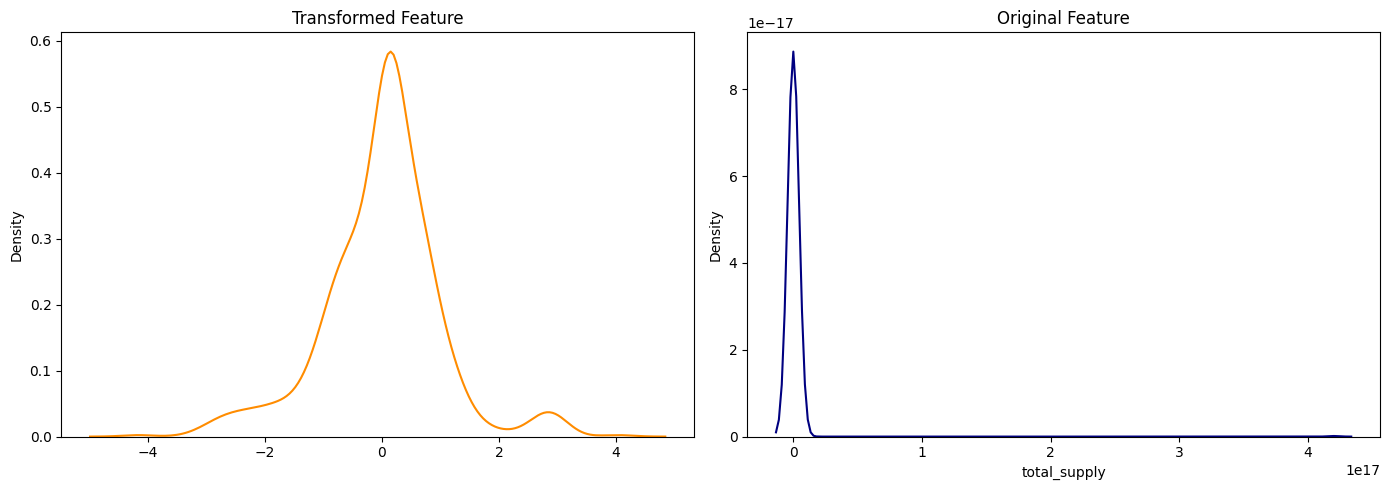

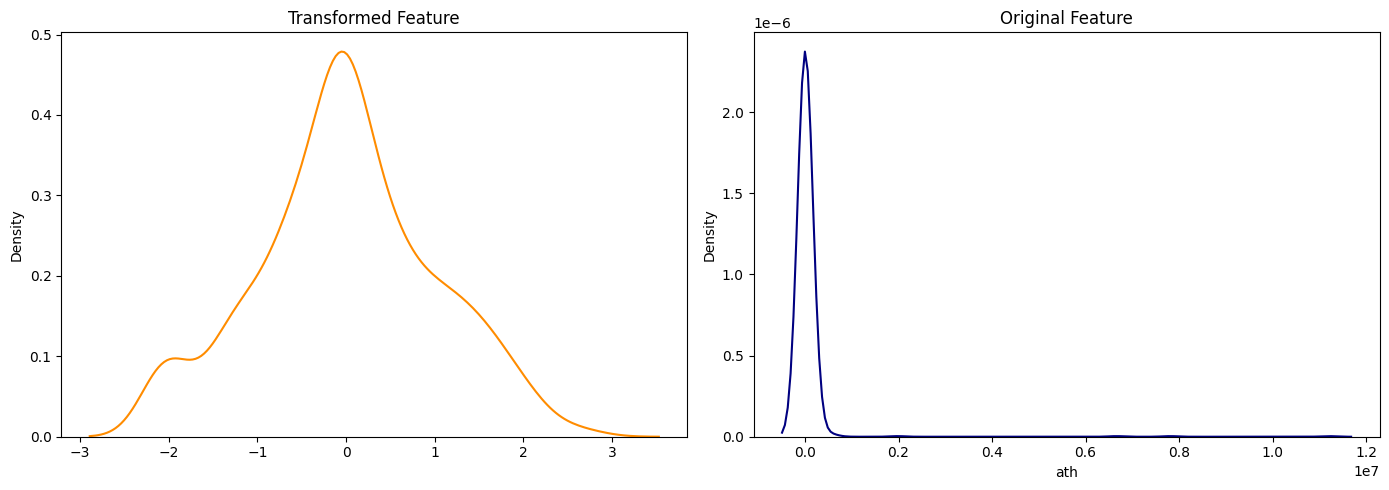

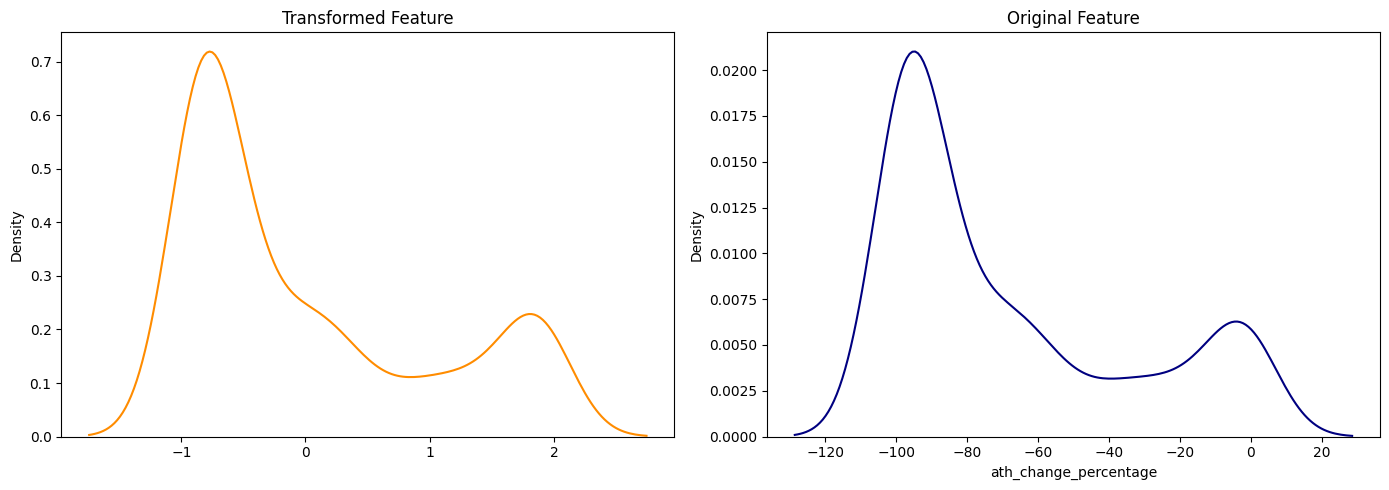

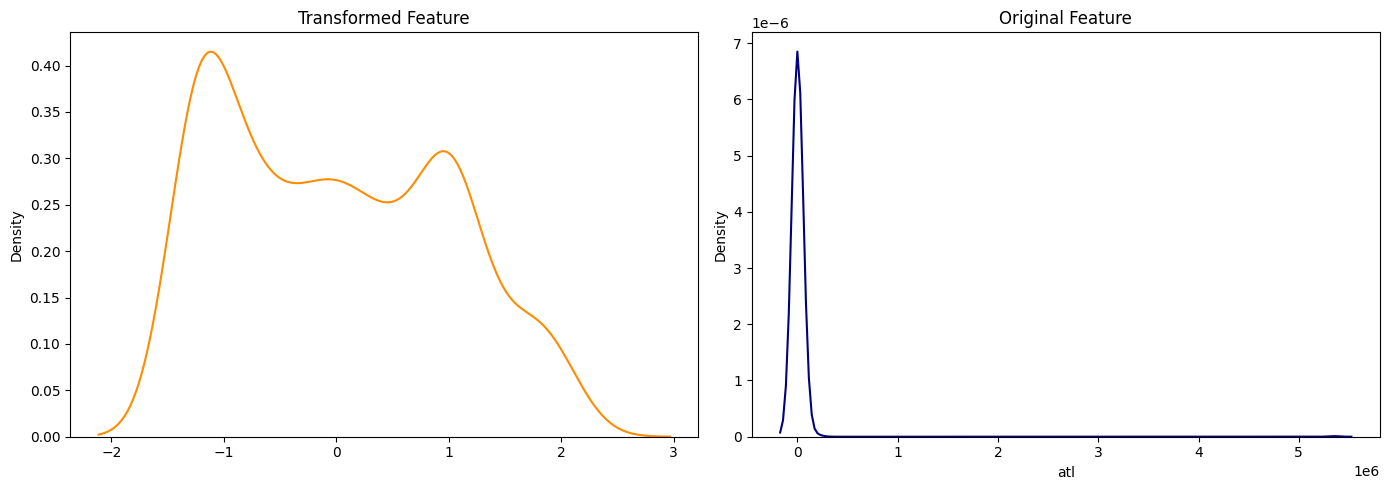

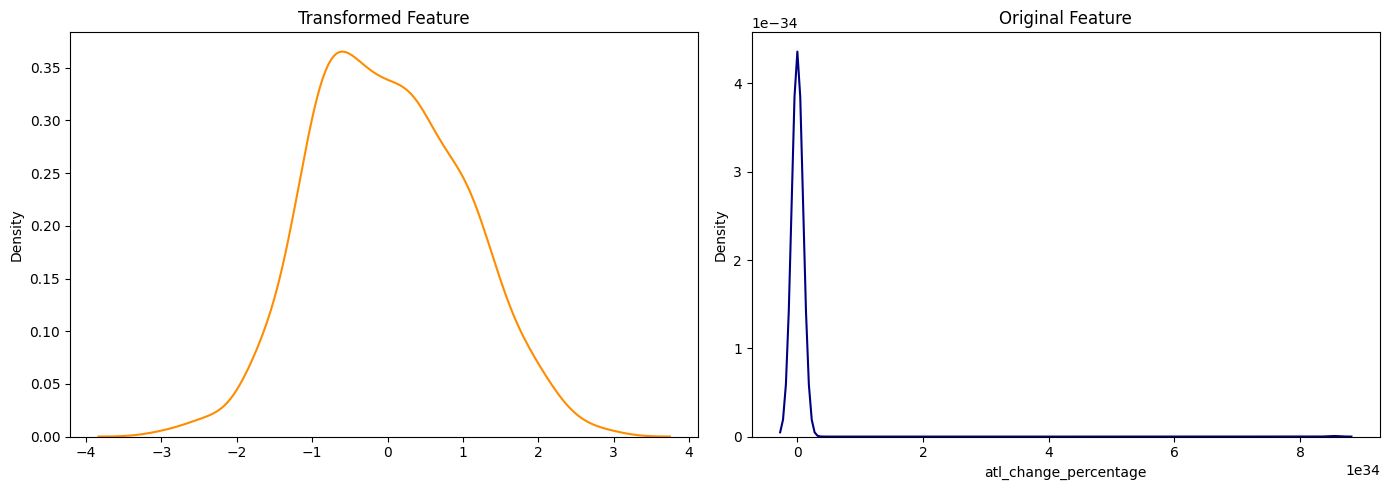

In [91]:
for i in range(10):
  kde(i)

In [155]:
rf1 = RandomForestClassifier(n_estimators = 200,max_depth = 10, oob_score = True)
rf1.fit(X_train_transform, y_train)
y_pred = rf1.predict(X_test_transform)
rf1.oob_score_


0.5871559633027523

In [156]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        Rest       0.63      0.62      0.62        71
     Top 10%       0.86      0.61      0.72        31
     Top 25%       0.53      0.58      0.55        33
     Top 50%       0.60      0.56      0.58        79
     Top 75%       0.44      0.52      0.48        67

    accuracy                           0.57       281
   macro avg       0.61      0.58      0.59       281
weighted avg       0.59      0.57      0.58       281



In [157]:
print(confusion_matrix(y_test, y_pred))

[[44  0  0  4 23]
 [ 0 19 11  1  0]
 [ 1  1 19 11  1]
 [ 8  1  5 44 21]
 [17  1  1 13 35]]


We dont really see much of a change in the random forest model upon normalisation of training data.

Using the Logistic regression model

In [158]:
# Labelling the target columns

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

y_train_transform = le.fit_transform(y_train)
y_test_transform = le.transform(y_test)
le.classes_

array(['Rest', 'Top 10%', 'Top 25%', 'Top 50%', 'Top 75%'], dtype=object)

In [159]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

lr.fit(X_train_transform, y_train_transform)
y_pred = lr.predict(X_test_transform)

In [162]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

print('accuracy', accuracy_score(y_test_transform, y_pred))
print('cvs', cross_val_score(lr, X_train_transform, y_train_transform).mean())

accuracy 0.4626334519572954
cvs 0.5091955372871404


In [164]:
print(classification_report(y_test_transform, y_pred))

              precision    recall  f1-score   support

           0       0.55      0.68      0.61        71
           1       0.82      0.45      0.58        31
           2       0.41      0.61      0.49        33
           3       0.47      0.34      0.40        79
           4       0.30      0.31      0.30        67

    accuracy                           0.46       281
   macro avg       0.51      0.48      0.48       281
weighted avg       0.48      0.46      0.46       281



Clearly the LogisticRegression model is performing poorly on this classification problem.